**איסוף נתונים והקמת תשתית SBERT**

---

**שימוש בבלאק בוקס בשם: SBERT **

---

**Sentence-BERT (SBERT):** is a modification of the pre-trained BERT network that uses siamese and triplet network structures to generate semantically meaningful sentence embeddings.

---
**Embeddings:** numerical representations of data—such as text, images, or audio—translated into vectors of real numbers that capture their semantic meaning.
in our case the SBERT model is creating a vector to each word/sentence while each vector has 384 numerical values which represent it's semantic value

---

**How does it help the project:** without this numerical value the computer only see the subjects: "machine learning" and "artificial intelligence" as just a string. The vectors we get from the embeddings are helpful because the model can "understand" that these words are connected semanticly

---

SBERT is a black box because its a transformer based model which was trained by miliards of sentences. To explain all the "Attention" lairs within it its a project in of itself. So in this project it will serve as a "translator" of text to vectors with numerical values

תחלופות אפשריות לאותו מודל והשוואותם למודל SBERT

---

**GloVe:** are also a type of model which can create semantic embeddings from words. The upside of this model is that its a faster model compared to SBERT. The downside of this model is that its  older then SBERT and it doesn't understand context very well its worse for difficult expressions

---

**TF-IDF:** is a simple statistical method which is great for searching words but can not "understand" meaning for example it will not know that "cat" and "dog" are connected.

---

**OpenAI embeddings:** have a very high quality but unfortunatly they require a payment and a connection to the internet within every exectution.

In [ ]:
from google.colab import drive
 #mounting drive in order to access the csv file which contains all the data
drive.mount('/content/drive')
concept_path="/content/drive/MyDrive/FinalProjectYodDaled/FFNN/words_category_FFNN.csv"

Mounted at /content/drive


In [ ]:
from sentence_transformers import SentenceTransformer
 #importing sentence_transomer library in order to load the SBERT model
import pandas as pd
# importing pandas in order to read the contents of a csv file which contains all of the concepts the FFNN(feed forward neural network )will work on
import numpy as np
#importing torch to make tensors of the concepts and labels
import torch
#the loading of the sbert model which counts as our black box
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

#reading all of the data from the file
df = pd.read_csv(concept_path)

# Define our labels for reference
class_names = [
    "Technology & Science",
    "History & Society",
    "Nature & Biology",
    "Arts & Culture",
    "Daily Life"
]

#printing the amount of words in each category within the csv file
print(f"Dataset loaded. Total concepts: {len(df)}")
print("Count per category:")
print(df['label'].value_counts().sort_index())

# Preview
df.head()
#creating a list which contains all of the concepts
concepts = df['word'].tolist()

#the creation of the embeddings from the sbert model using the enode function
embeddings = model_sbert.encode(concepts)
#explenation of the encode function
#Tokenization: the SBERT model breaks the words into "tokens"- sub words
#Contextual Encoding: It passes these tokens through layers of Self Attention
#Pooling: It takes the mathematical outputs of all tokens and averages them into a single 384-dimentional vector

X = torch.tensor(embeddings).float() #tensor which has the concept as an embedded vector
y = torch.tensor(df['label'].values).long() #tensor which has the label values as tensor

print(f"the amount of sentences/words {len(embeddings)} shape of embeddings{embeddings.shape}")
#prints amount of words and their shapes

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dataset loaded. Total concepts: 1001
Count per category:
label
0    201
1    200
2    200
3    200
4    200
Name: count, dtype: int64
the amount of sentences/words 1001 shape of embeddings(1001, 384)


Now that every sentence/word has a vector which represent its numerical value from the SBERT model embeddings. We now can create the FFNN(feed forward neural network) which the goal of it is to assign to each and every word a category. it trains with a large data set of hundred words to every category. I design the categories to be broad so they could cover the most amount of topics

**יצירת FFNN**

---

**FFNN description:**  the simplest type of artificial neural network where information moves in only one direction—forward—from input nodes, through hidden layers, to output nodes. It uses weighted connections and activation functions to model complex, non-linear relationships, primarily for classification and regression tasks without feedback loops.

---

**what this FFNN do:** the neural network gets the 384 dimentions vector it moves it through the hidden layer to decide which category does the word close to the most

---

**how does it help the project:** this network alows to categories new words it never knew. This network allows to automatically clasify new words.

**FFNN architecture**

---

FFNN is a neural network which I design and define the exact flow of information.

---

**The math behind the layers of this network:** the linear lair which performs the transformation is y = x*A^T + b.

> y = x*A^T + b

explenation: "x" is the input vector which 384 dimentions. "A" is the weight matrix the "knowledge" the model learns. "b" is bias


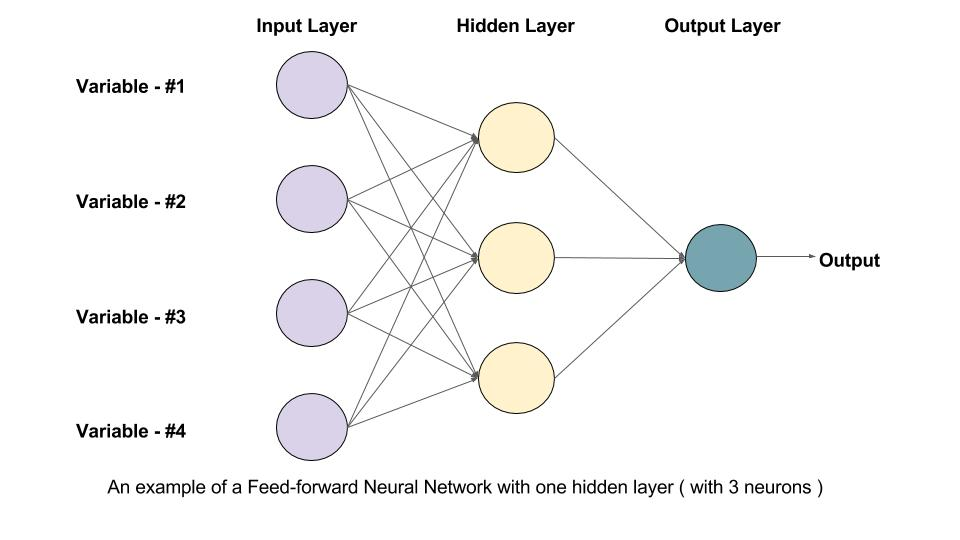

**The layers of the FFNN**

---

 **Input Layer: The Data "Translator":**  this is called the input layer within the network. this layer doesn't actually proccess anything it is the interface of the network.

*   **The Function:** It holds the 384 numbers we got from SBERT model. each neuron in this layer represents one dimention of the semantic vector.
*   **Analogy:** Imagine you are trying to identify a fruit. The input layer is the set of raw measurements: weight, color, texture, and sugar content. It just presents the facts to the network.

*   **The function in the project:** because SBERT outputs 384 values we must have exactly 384 input neurons. if we had 383 or 385 instead a matrix mismatch would happen

---
**Hidden Layer: The "Feature Extractor":** this layer is the main layer of the FFNN where the calculations take place. In short this layer looks for relations between the 384 input numbers

*   **The Function:** It calculates a weighted sum of all inputs. Each of the 128 neurons in this layer is looking for a specific "pattern." For example, one neuron might learn to fire only when it sees a combination of numbers that usually represent "technology," while another looks for "historical dates."

*   **The Math:** Each neuron perform this calculation: ReLU(sum(weight*input)+bias)
*   **The Activation (ReLU):** This is crucial. Without ReLU, the network is just a giant linear equation. ReLU allows the model to learn complex, non-linear boundaries—like the fact that "Evolution" (Biology) and "Revolution" (History) are linguistically similar but belong to totally different categories.
---
the reasons I choose 128 neurons in the hidden layer:
1.   **The Information Bottleneck:** We are going from 384 (input) → 128 (hidden) → 5 (output). We want the network to compress the information. If the hidden layer was too large (e.g., 1000 neurons), the network would just "memorize" the data (Overfitting). If it was too small (e.g., 10 neurons), it wouldn't have enough "brain power" to distinguish between 5 complex categories.
2.   **Power of Two:** Computer hardware (GPUs/CPUs) is optimized to process data in powers of two (32,64,128,256) and 256 is too close to 384 so it would also could "memorize" the data while 32 and 64 dont have enough "brain power" thats why 128 seems the better number

---

**The Output Layer: The "Final Jury"**

*   **Function:** It reduces the 128 complex patterns down to 5 numbers—one for each of your categories

*   **How it works:** The neuron with the highest value (score) is the model's prediction.If the "History" neuron outputs 8.5 and the "Science" neuron outputs 1.2, the model classifies the concept as History.
in the project we use 5 neurons for each of the 5 categories











**explanations of the chosen activation function:** ReLU (Rectified Linear Unit) is the most popular activation function in deep learning for a reason. Its formula is simple:

> f(x)=max(0,x).
*   **How it works:** If a neuron's signal is negative, ReLU turns it to 0 (kills the signal). If it's positive, it passes it through as is.
*   **The "Why":** Without ReLU, the network is just one big linear equation (a simple line). ReLU allows the network to learn non-linearities. for example, the boundary between "Arts" and "Technology" isn't a straight line; it's a complex shape in 384D space. ReLU allows the model to "bend" its logic to fit that shape.
**Comparison to other functions:**

*   **Sigmoid:** An older function that squashes values between 0 and 1. It is rarely used in hidden layers today because of the Vanishing Gradient problem (the model stops learning because the signals become too small).

*   **Tanh:** Squashes values between -1 and 1. Better than Sigmoid, but still slower to train than ReLU.
*   **Leaky ReLU:** Similar to ReLU but allows a tiny bit of the negative signal through.






**explanation of the dropout:** the dropout prevents overfitting and it does so by shutting of a percent of the neurons in order to not reach overfit

---
**the reason the dropout os at 0.2:** 0.1 (10%): Too little. The model might still memorize the data.
0.5 (50%): Too much. its are throwing away half of the brainpower; the model will take forever to learn (Underfitting). 0.2 (20%): This is the standard industry starting point. It provides enough "noise" to make the model robust without making the task impossible. Tell your teacher: "I chose 0.2 as a balanced hyperparameter to ensure generalization across my 5 categories."

**explanation of the nn.Linear in FC1 and FC2:** Function: Every input neuron is connected to every output neuron. This is essential for Global Feature Recognition.

---
**other types of layers:**

*   **CNN (Convolutional):** These are for images/spatial data. They look for local patterns (like edges). Since your SBERT vector is a mathematical summary, there are no "pixels" to look at.
*   **RNN/LSTM (Recurrent):** These are for sequences (reading a sentence word by word). But SBERT has already done that work for you! SBERT converted the sequence into a single "thought vector."




experiments for checking the most optimized neural network

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- 1. PREPARE DATA (The Train-Test Split) ---
# We take 20% of the 1000 words and hide them from the model.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #seperating the data into 0.8 training data and 0.2 test data

In [ ]:

# Define the Architecture
class MindMapClassifier(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=128, num_classes=5):
        """
        input_dim: 384 (Fixed by SBERT output)
        hidden_dim: 128 (Our 'Brain Power' - where patterns are found)
        num_classes: 5 (Your specific categories)
        """
        super(MindMapClassifier, self).__init__()

        # 1. Input Layer -> Hidden Layer
        # Takes 384 features and expands/filters them into 128 patterns
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        #note: this layer creates 49,152 weights which equals: 128*384 every neuron of the input_dim is connected to every input of the hidden_dim

        # 2. Activation Function (ReLU)
        # Allows the model to learn non-linear relationships
        self.relu = nn.ReLU()

        # 3. Dropout Layer
        # Randomly shuts off 20% of neurons during training to prevent memorization
        self.dropout = nn.Dropout(0.2)

        # 4. Hidden Layer -> Output Layer
        # Condenses the 128 patterns into 5 final category scores
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        #note: this layer creates 640 weights which equals: 128*5 every neuron of the hidden_dim is connected to every input of the num_classes

        #How do the weights determine the Loss?
        #Prediction: The model multiplies the input vector (384 numbers) by the first weight matrix. The result is passed through ReLU (which filters out negative values) and then multiplied by the second matrix.
        #Score: In the end, 5 numbers are obtained (Scores).
        #Penalty (Loss): The CrossEntropyLoss function looks at this error. If the weights caused an incorrect prediction, the Loss will be high.
        #Direct effect: The more a particular weight "pushed" the prediction in the wrong direction, the stronger the "correction" it will receive from the optimizer (Adam).
    def forward(self, x):
        # This is the "Forward Pass" - how data flows through the network
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out


In [ ]:
# --- 2. CONFIGURABLE HYPERPARAMETERS ---
HIDDEN_SIZE = 128 #amount of neurons in the hidden layer
DROPOUT = 0.2 #amount of neurons to deactivate in the training phase
#At each training step, the model randomly "turns off" 20% of the neurons in the hidden layer. This forces the remaining weights to not rely on one specific neuron ("genius neuron").
LR = 0.01 #the learning rate of the optimizer
#Step size: How big the step you take down will be. If the LR is too big (e.g. 0.9), you might skip over the valley to the other side. If it is too small (0.0001), it will take you forever to get there.
EPOCHS = 100 #the amount of epochs/ the amount of time going through all of the dataSet and improving weights accordingly

model = MindMapClassifier(input_dim=384, hidden_dim=HIDDEN_SIZE, num_classes=5)
# Re-apply dropout if you changed the class
model.dropout = nn.Dropout(DROPOUT)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Lists to track progress
train_losses, test_losses = [], []
train_accs, test_accs = [], []

In [ ]:
# --- 3. THE EXPERIMENTAL LOOP ---
for epoch in range(EPOCHS):
    # --- Training Phase ---
    #this line is to activate the model in training mode
    model.train()
    #this line is to reset the gradient decent step. for each epoch the model checks the weights and updates them, so we need to reset the calculation each epoch to not add to previous "mistake"
    optimizer.zero_grad()

    #these 2 lines represent the forward pass and bring us the resulted loss we have "the error in the model"
    train_outputs = model(X_train)
    train_loss = criterion(train_outputs, y_train)

    #this line are for doing backpropogation it counts how each of the weight contributed for the loss
    train_loss.backward()
    #this line is for updating the weights depending on how much they impacted the loss with optimizer Adam
    optimizer.step()

    # --- Validation Phase (The "Test") ---
    model.eval() # Turn off Dropout
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)

        # Calculate Accuracies
        train_acc = (torch.max(train_outputs, 1)[1] == y_train).sum().item() / y_train.size(0)
        test_acc = (torch.max(test_outputs, 1)[1] == y_test).sum().item() / y_test.size(0)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss {train_loss.item():.4f} | Test Acc {test_acc*100:.1f}%")

Epoch 0: Train Loss 1.6129 | Test Acc 52.7%
Epoch 10: Train Loss 0.6677 | Test Acc 81.1%
Epoch 20: Train Loss 0.3448 | Test Acc 81.1%
Epoch 30: Train Loss 0.1944 | Test Acc 80.6%
Epoch 40: Train Loss 0.1258 | Test Acc 76.1%
Epoch 50: Train Loss 0.0957 | Test Acc 75.1%
Epoch 60: Train Loss 0.0816 | Test Acc 74.6%
Epoch 70: Train Loss 0.0762 | Test Acc 76.1%
Epoch 80: Train Loss 0.0714 | Test Acc 75.6%
Epoch 90: Train Loss 0.0734 | Test Acc 74.6%


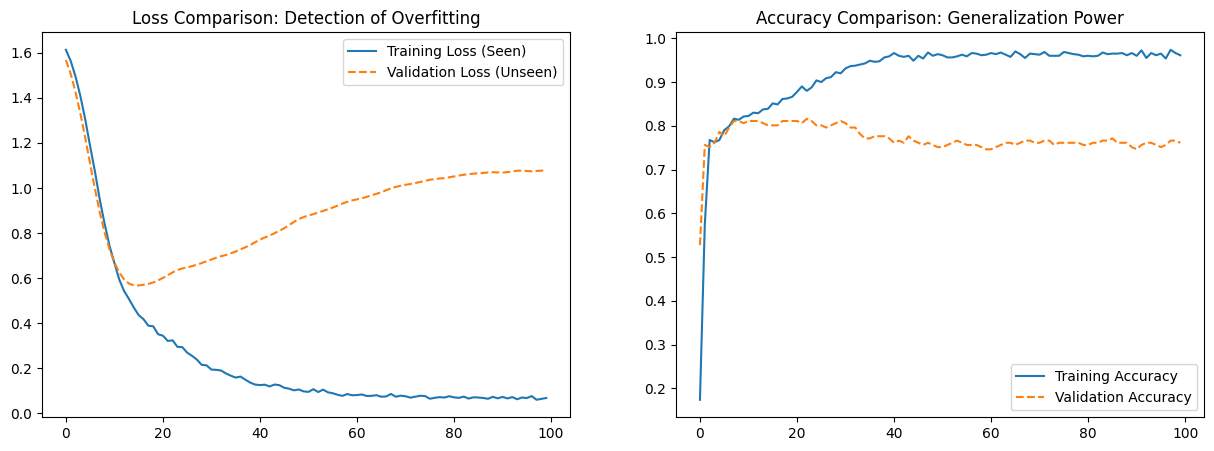

In [ ]:
# --- 4. VISUALIZATION ---
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss (Seen)')
plt.plot(test_losses, label='Validation Loss (Unseen)', linestyle='--')
plt.title('Loss Comparison: Detection of Overfitting')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training Accuracy')
plt.plot(test_accs, label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Comparison: Generalization Power')
plt.legend()
plt.show()

In [ ]:
# Save the 'Brain' of the project
torch.save(model.state_dict(), 'mindmap_model.pth')
print("Model weights saved to mindmap_model.pth")

Model weights saved to mindmap_model.pth


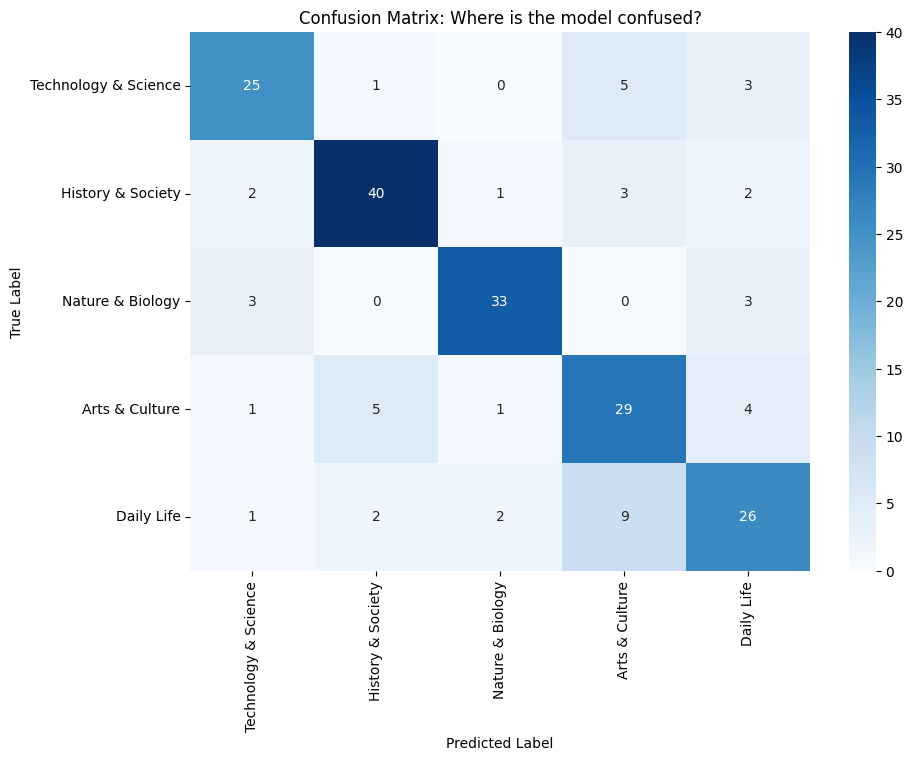

                      precision    recall  f1-score   support

Technology & Science       0.78      0.74      0.76        34
   History & Society       0.83      0.83      0.83        48
    Nature & Biology       0.89      0.85      0.87        39
      Arts & Culture       0.63      0.72      0.67        40
          Daily Life       0.68      0.65      0.67        40

            accuracy                           0.76       201
           macro avg       0.76      0.76      0.76       201
        weighted avg       0.77      0.76      0.76       201



In [ ]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Switch to evaluation mode (Turns off Dropout)
model.eval()

# 2. Get predictions
with torch.no_grad(): # Disable gradient calculation to save memory
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_test, predicted)

# 4. Plotting it
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Where is the model confused?')
plt.show()

# 5. Print a detailed report
print(classification_report(y_test, predicted, target_names=class_names))

As you can see in the confusion matrix which is the result of the models predictions. this FFNN isn't perfect but it does have really good result only being wrong 10 times. it has very good accuarcy.

I do think this model is strong and not in overfit since I now visualized the learning curve of the training accuarcy and also compared it to the validation accuarcy. also this code reaches 97.5% and not 100% which is a lot but it is possible because this entire model works with the SBERT embeddings so it means that the semantic embeddings between my categories are high enough it can see the difference between them.